[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

# Transfer Learning: Adaptando a ResNet18 para o dataset MNIST

Neste projeto, vamos aplicar o conceito de Transfer Learning usando a arquitetura da ResNet18, pré-treinada no dataset ImageNet, e adaptá-la para o dataset MNIST.

Vamos usar diferentes abordagens de congelamento de pesos para ver qual perfoma melhor.

## Introdução ao Transfer Learning

### O que é Transfer Learning?
Transfer Learning é uma técnica onde um modelo desenvolvido e treinado para uma tarefa específica é reutilizado como ponto de partida para uma segunda tarefa. Exemplo, se uma pessoa sabe patinar no gelo, é muito mais fácil ensiná-la a esquiar na neve, pois as habilidades base de equilíbrio e deslize são similares. Na computação, transferimos os pesos de uma rede que já aprendeu a enxergar bordas, formas, transições de luz, etc. para resolver um problema novo muito mais rapido.

### A Importância do Pré-treinamento em Deep Learning
Treinar redes neurais profundas do zero exige quantidades gigantescas de dados rotulados e um altíssimo poder computacional. O pré-treinamento permite contornar esse problema. Ao usar um modelo pré-treinado, podemos alcançar acurácias altíssimas mesmo usando poucos dados, além de acelerar drasticamente o tempo de convergência.

### Extração de Características vs. Fine-Tuning

* Extração de Características: É quando congelamos todos os pesos da rede pré-treinada e trocamos apenas a última camada. A rede age apenas como um extrator de padrões visuais estáticos. Ela não aprende nada novo nas bases, treinamos so a ultima camada.
* Fine-Tuning: É ideial quando precisamos de um ajuste e adaptação maior, nessa tecnica, descongelamos algumas ou todas as camadas da rede para o treinamento. Isso permite que a rede adapte a decisão final e seus filtros internos para se adequar melhor ao novo conjunto de dados. Essa abirdagem exige uma taxa de aprendizado menor para não destruir os pesos originais.

### Resumo das Anotações da Leitura: Introduction to Transfer Learning Algorithms and Practice - Capítulo 8
O Capítulo 8 foca nos métodos baseados em parâmetros, Pre-Training e Fine-Tuning, para Transfer Learning profundo. A ideia principal é que redes neurais profundas aprendem representações hierárquicas.

As primeiras camadas extraem características genéricas como bordas, curvas e texturas, que servem pra quase todas tarefas visuais. Já as últimas camadas aprendem características altamente específicas, como orelhas de gato ou rodas de carro.
Por isso, o conteudo transferido de uma rede depende de quão similares são os domínios de origem e destino. O capítulo também aborda a importância de técnicas de regularização durante o fine-tuning para evitar que o modelo sofra de instabilidade e perca o conhecimento útil já adquirido.

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de treinamento/avaliação selecionado: {device}')

Dispositivo de treinamento/avaliação selecionado: cuda


#### Preparando o DATASET [MNIST](https://en.wikipedia.org/wiki/MNIST_database) para a ResNet18

O MNIST e o ResNet18 com as imagens do ImageNet tem muitas diferenças na escalas e nas cores, vou normalizar as caracteristicas para aproveitar os pesos pré-treinados.

In [2]:
# MNIST dataset
root_path = '/home/ghca/Downloads'

# Transformação para adequar o MNIST ao ResNet18
trans = transforms.Compose([
    transforms.Resize(224), # Redimensionar o tamanho
    transforms.Grayscale(num_output_channels=3), # Aumento de canais do MNIST 3
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.38MB/s]


In [4]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/ghca/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=3)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [5]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: /home/ghca/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=3)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

O dataset MNIST original tem 60.000 imagens de treino e 10.000 de teste.
Vou implementar o `DataLoader` para agrupar esses dados em lotes para alimentar o modelo.

In [6]:
batch_size = 32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamanho do DataLoader de treino: {len(train_loader)} batches de {batch_size}")

Tamanho do DataLoader de treino: 1875 batches de 32


## Construindo o Modelo usando Transfer Learning com ResNet18

Seram testadas 4 estratégias de transferência de aprendizado.

* do_zero
* apenas_fc
* fine_tuning_parcial
* fine_tuning_total

Para isso, criei uma função `get_resnet_model` que configura a arquitetura de acordo com a estratégia testada.

A ResNet18 do ImageNet prevê 1000 classes, para adaptar, a última camada foi trocada para prever apenas as 10 classes do MNIST.

In [7]:
import torch.nn as nn
from torchvision import models

def get_resnet_model(strategy="fine_tuning_total"):
    """ Retorna o modelo ResNet18 configurado para a estratégia testada. """

    if strategy == "do_zero":
        # Sem pesos pré-treinados
        model = models.resnet18(weights=None)
    else:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if strategy == "apenas_fc":
        # Congela os parâmetros originais da rede
        for param in model.parameters():
            param.requires_grad = False
    elif strategy == "fine_tuning_parcial":
        # Congela tudo primeiro
        for param in model.parameters():
            param.requires_grad = False
        # Descongela apenas o último bloco
        for param in model.layer4.parameters():
            param.requires_grad = True

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)
    return model.to(device)

# teste
model = get_resnet_model(strategy="fine_tuning_total")
print("Modelo ResNet18 carregado e modificado.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Modelo ResNet18 carregado e modificado.


Para entender o impacto de cada estratégia, podemos contar quantos parâmetros serão efetivamente treinados pelo otimizador.

In [9]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

estrategias = ["do_zero", "apenas_fc", "fine_tuning_parcial", "fine_tuning_total"]

print("Contagem de Parâmetros Treináveis por Estratégia:")
for est in estrategias:
    temp_model = get_resnet_model(strategy=est)
    _, treina = count_parameters(temp_model)
    print(f"- {est}: {treina:,} parâmetros")

# Liberar memória
del temp_model

Contagem de Parâmetros Treináveis por Estratégia:
- do_zero: 11,181,642 parâmetros
- apenas_fc: 5,130 parâmetros
- fine_tuning_parcial: 8,398,858 parâmetros
- fine_tuning_total: 11,181,642 parâmetros


## Salvando o Modelo

Vou salvar o treinamento para não perde os pesos treinados, escolhendo sempre o melhor modelo de cada estratégia.

In [10]:
from google.colab import drive
import os

drive.mount('/content/drive')
caminho_salvamento_drive = '/content/drive/MyDrive/Modelos_TransferLearning/'
if not os.path.exists(caminho_salvamento_drive):
    os.makedirs(caminho_salvamento_drive)
    print(f"Pasta criada em: {caminho_salvamento_drive}")
else:
    print(f"Pasta já existente em: {caminho_salvamento_drive}")

Mounted at /content/drive
Pasta criada em: /content/drive/MyDrive/Modelos_TransferLearning/


## Loop de Treinamento e Otimizador

Os modelos que não foram congelados receberam o otimizador Adam.

In [11]:
from torch.optim import Adam
import time
import os

# Hiperparâmetros gerais
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-4
epochs = 5

# Lista das 4 estratégias
estrategias = ["do_zero", "apenas_fc", "fine_tuning_parcial", "fine_tuning_total"]

# Dicionário para guardar o histórico
resultados_historico = {}

print("Iniciando o Treinamento das 4 Estratégias:")

for estrategia in estrategias:
    print("\n")
    print(f"Treinando Estratégia: {estrategia.upper()}")

    # Carrega o modelo e configura otimizador
    model = get_resnet_model(strategy=estrategia)
    parametros_para_treinar = [p for p in model.parameters() if p.requires_grad]
    optimizer = Adam(parametros_para_treinar, lr=learning_rate)

    caminho_arquivo = os.path.join(caminho_salvamento_drive, f'melhor_modelo_{estrategia}.pth')

    # Variáveis de controle para estratégia atual
    loss_treino_hist, acc_treino_hist = [], []
    loss_val_hist, acc_val_hist = [], []
    melhor_acuracia_val = 0.0

    start_time = time.time()

    # Loop de Épocas
    for epoch in range(epochs):
        # --- TREINO ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # --- MÉTRICAS DA ÉPOCA ---
        val_acc_media = val_correct / val_total
        loss_treino_hist.append(train_loss / len(train_loader))
        acc_treino_hist.append(train_correct / train_total)
        loss_val_hist.append(val_loss / len(test_loader))
        acc_val_hist.append(val_acc_media)

        print(f"  Época [{epoch+1}/{epochs}] | Acc Treino: {round((train_correct/train_total)*100,2)}% | Acc Val: {round(val_acc_media*100,2)}%")

        # Salva o melhor modelo
        if val_acc_media > melhor_acuracia_val:
            melhor_acuracia_val = val_acc_media
            torch.save(model.state_dict(), caminho_arquivo)
            print(f"  ---> Novo recorde para {estrategia}! Salvo no Drive.")

    tempo_total = (time.time() - start_time) / 60
    print(f"Tempo total ({estrategia}): {round(tempo_total, 2)} minutos.\n")

    # Dados do discionario
    resultados_historico[estrategia] = {
        'loss_treino': loss_treino_hist,
        'acc_treino': acc_treino_hist,
        'loss_val': loss_val_hist,
        'acc_val': acc_val_hist,
        'melhor_acc': melhor_acuracia_val,
        'tempo_minutos': tempo_total
    }

print("Todos os treinamentos foram concluidos!")

Iniciando o Treinamento das 4 Estratégias:


Treinando Estratégia: DO_ZERO
  Época [1/5] | Acc Treino: 96.77% | Acc Val: 98.12%
  ---> Novo recorde para do_zero! Salvo no Drive.
  Época [2/5] | Acc Treino: 98.85% | Acc Val: 98.2%
  ---> Novo recorde para do_zero! Salvo no Drive.
  Época [3/5] | Acc Treino: 99.11% | Acc Val: 99.13%
  ---> Novo recorde para do_zero! Salvo no Drive.
  Época [4/5] | Acc Treino: 99.33% | Acc Val: 99.33%
  ---> Novo recorde para do_zero! Salvo no Drive.
  Época [5/5] | Acc Treino: 99.38% | Acc Val: 99.04%
Tempo total (do_zero): 23.72 minutos.



Treinando Estratégia: APENAS_FC
  Época [1/5] | Acc Treino: 80.56% | Acc Val: 91.15%
  ---> Novo recorde para apenas_fc! Salvo no Drive.
  Época [2/5] | Acc Treino: 91.06% | Acc Val: 93.15%
  ---> Novo recorde para apenas_fc! Salvo no Drive.
  Época [3/5] | Acc Treino: 92.67% | Acc Val: 94.06%
  ---> Novo recorde para apenas_fc! Salvo no Drive.
  Época [4/5] | Acc Treino: 93.42% | Acc Val: 94.46%
  ---> Novo recorde 

### Carregando o Melhor Modelo do Drive

In [12]:
import os
import torch

print("Verificando arquivos salvos no Drive:")
arquivos_no_drive = os.listdir(caminho_salvamento_drive)
for arq in arquivos_no_drive:
    print(f" - {arq}")
print("-" * 40)

modelos_carregados = {}
estrategias = ["do_zero", "apenas_fc", "fine_tuning_parcial", "fine_tuning_total"]

for est in estrategias:
    caminho_arquivo = os.path.join(caminho_salvamento_drive, f'melhor_modelo_{est}.pth')

    if os.path.exists(caminho_arquivo):
        modelo_temp = get_resnet_model(strategy=est)
        pesos_salvos = torch.load(caminho_arquivo, map_location=device)
        modelo_temp.load_state_dict(pesos_salvos)
        modelo_temp.eval()
        modelos_carregados[est] = modelo_temp
        print(f"Pesos do modelo '{est}' carregados e acoplados com sucesso!")
    else:
        print(f"Arquivo não encontrado para a estratégia: {est}")

Verificando arquivos salvos no Drive:
 - melhor_modelo_do_zero.pth
 - melhor_modelo_apenas_fc.pth
 - melhor_modelo_fine_tuning_parcial.pth
 - melhor_modelo_fine_tuning_total.pth
----------------------------------------
Pesos do modelo 'do_zero' carregados e acoplados com sucesso!
Pesos do modelo 'apenas_fc' carregados e acoplados com sucesso!
Pesos do modelo 'fine_tuning_parcial' carregados e acoplados com sucesso!
Pesos do modelo 'fine_tuning_total' carregados e acoplados com sucesso!


### Análise Gráfica Comparativa

Para detectar overfitting e comparar a convergência das 4 estratégias, vou plotar as curvas de validação de todos os modelos sobrepostas.

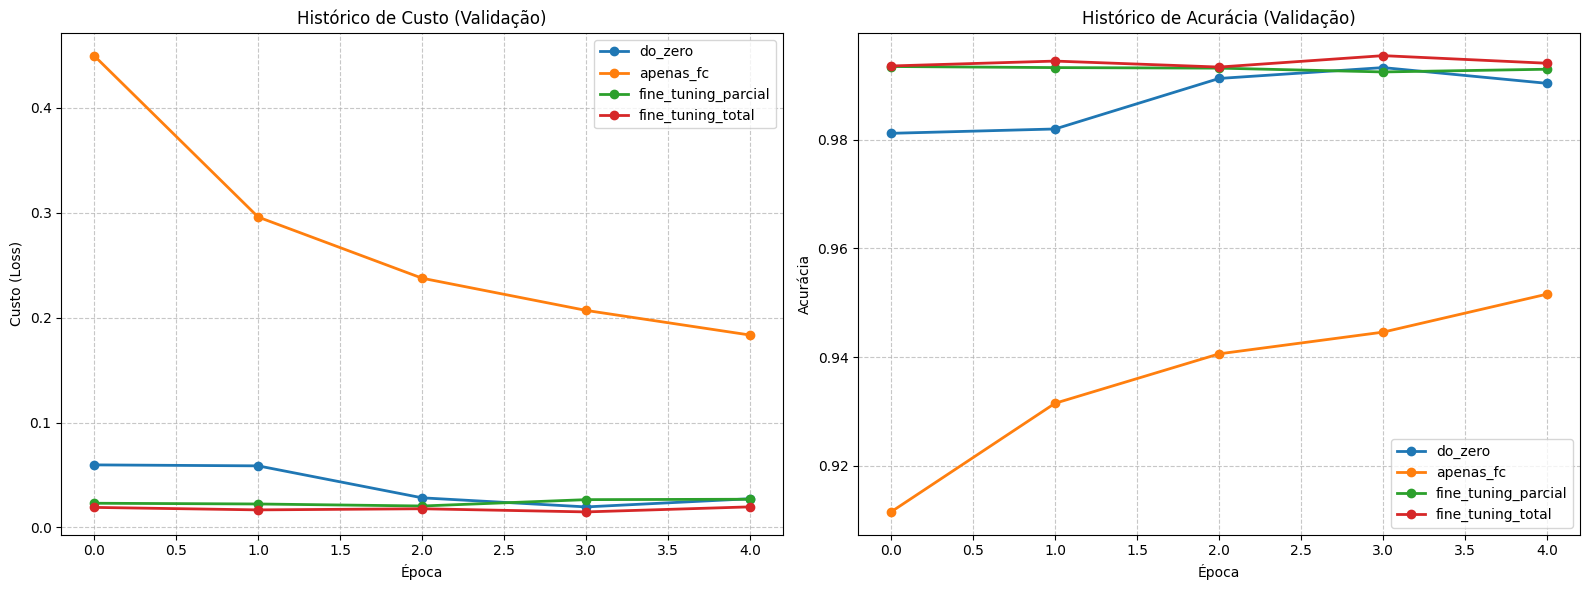

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

# Gráfico de Perda na Validação
plt.subplot(1, 2, 1)
for est, dados in resultados_historico.items():
    plt.plot(dados['loss_val'], label=est, marker='o', linewidth=2)
plt.title('Histórico de Custo (Validação)')
plt.xlabel('Época')
plt.ylabel('Custo (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico de Acurácia na Validação
plt.subplot(1, 2, 2)
for est, dados in resultados_historico.items():
    plt.plot(dados['acc_val'], label=est, marker='o', linewidth=2)
plt.title('Histórico de Acurácia (Validação)')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Acurácia e F1-Score

Cálculos da a Acurácia final e o F1-Score para montar a tabela comparativa.

In [16]:
from sklearn.metrics import f1_score
import numpy as np

print("Resultados para Tabela Comparativa\n")

for est, modelo in modelos_carregados.items():
    modelo.eval()
    todas_preds = []
    todas_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelo(images)
            _, predicted = torch.max(outputs.data, 1)

            # Move para CPU e converte para numpy para o sklearn poder calcular
            todas_preds.extend(predicted.cpu().numpy())
            todas_labels.extend(labels.cpu().numpy())

    acc_teste = np.mean(np.array(todas_preds) == np.array(todas_labels))
    f1_teste = f1_score(todas_labels, todas_preds, average='macro')
    tempo = resultados_historico[est]['tempo_minutos']

    print(f" Estratégia: {est.upper()}")
    print(f" Acurácia: {acc_teste*100:.2f}%")
    print(f" F1-Score: {f1_teste:.4f}")
    print(f" Tempo   : {tempo:.2f} min")
    print("-" * 40)

Resultados para Tabela Comparativa

 Estratégia: DO_ZERO
 Acurácia: 99.33%
 F1-Score: 0.9932
 Tempo   : 23.72 min
----------------------------------------
 Estratégia: APENAS_FC
 Acurácia: 95.16%
 F1-Score: 0.9509
 Tempo   : 13.88 min
----------------------------------------
 Estratégia: FINE_TUNING_PARCIAL
 Acurácia: 99.35%
 F1-Score: 0.9935
 Tempo   : 15.26 min
----------------------------------------
 Estratégia: FINE_TUNING_TOTAL
 Acurácia: 99.55%
 F1-Score: 0.9955
 Tempo   : 23.47 min
----------------------------------------


## Tabela Comparativa dos Resultados

| Estratégia | Camadas Treinadas | Acurácia no Teste | F1-Score | Tempo | Observações |
| :--- | :--- | :--- | :--- | :--- | :--- |
| ResNet18 do zero | Todas | 99.33% | 0.9932 | 23.72 min | Resultado excelente, mas demorado. |
| Apenas FC | `fc` | 95.16% | 0.9509 | 13.88 min | Mais rápido, mas peca na alta precisão. |
| Fine-tuning parcial| `layer4` + `fc` | 99.35% | 0.9935 | 15.26 min | Vencedor!! Alta acurácia com economia de tempo. |
| Fine-tuning total | Todas | 99.55% | 0.9955 | 23.47 min | Melhor acurácia, mas custo de tempo alto. |

---

## Análise dos Resultados

### Qual estratégia apresentou melhor resultado?
A estratégia de Fine-tuning Total obteve a melhor acurácia (99.55%). Porém, o Fine-tuning Parcial foi o mais eficiente, pois atingiu um resultado praticamente idêntico (99.35%) sendo 8 minutos mais rápido.

### O treinamento do zero foi melhor ou pior que o uso de pesos pré-treinados?
O treinamento foi equivalente em acurácia (99.33%), mas pior em eficiência. O treinamento do zero levou 23.72 minutos para chegar onde o Fine-tuning parcial chegou em apenas 15.26 minutos.

### Treinar apenas a camada FC foi suficiente?
Não para uma aplicação de alta performance. Embora 95.16% pareça alto, no MNIST isso é considerado baixo. Isso mostra que as características genéricas da ImageNet precisam de um "ajuste fino" para entender o domínio específico de dígitos manuscritos.

### O fine-tuning parcial trouxe ganhos?
Sim, foram ganhos significativos. Ele saltou de 95.16% para 99.35% de acurácia. O descongelamento da `layer4` permitiu o modelo adaptar melhor seus filtros para o dataset.

###  O fine-tuning total melhorou o desempenho ou causou instabilidade?
Melhorou o desempenho, atingindo o pico de 99.55%. Não houve instabilidade porque utilizamos uma taxa de aprendizado controlada, isso permitiu um ajuste suave dos pesos.

###  A ResNet18 pré-treinada no ImageNet é uma boa escolha para o MNIST?
Para fins de estudo de Transfer Learning, sim. Na prática, foi possivel alcançar resultados similares sem usar um modelo tão pesado para um dataset simples. Entretanto os resultados mostram que a arquitetura é extremamente robusta e capaz de aprender o problema com perfeição.

###  O que os resultados mostram sobre a importância da similaridade entre os datasets?
O ImageNet e o MNIST são bem diferentes, foi preciso fazer ajustes para alinhar os datasets, mas os resultados provam que com os ajustes certos, se possiveis, é possivel conseguir otimos resultados.